In [1]:
import librosa
import numpy as np
import pandas as pd
import scipy

In [2]:
import nest_asyncio
import asyncio

In [3]:
import os
import sys
import re
import tempfile

In [4]:
import pyaudio
from IPython.display import Audio, display
from ipywidgets import Button

In [5]:
from fastapi import FastAPI, File, UploadFile, Form, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import FileResponse, HTMLResponse, RedirectResponse
from fastapi.staticfiles import StaticFiles
from fastapi.staticfiles import StaticFiles
import uvicorn

In [6]:
import seaborn as sns

In [7]:
import tensorflow as tf
import kagglehub

I0000 00:00:1779652309.705959   33819 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779652309.858365   33819 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779652315.075585   33819 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Loading in all the data from the horns dataset

In [8]:
anchoring_data = pd.read_csv('horns/labels.csv')
#anchoring_data = anchoring_data[:-3]
anchoring_data

,file_name,labels
0,12-VIBROMAX-VX-PAIR.mp3,CAR/TRUCK
1,5-MEGASONIC-MS-PAIR.mp3,CAR/TRUCK/BUS
2,19-Supersonic-SS-PAIR.mp3,CAR/TRUCK/JEEP
3,RSA2-Pair.mp3,CAR/TRUCK
4,14-VIBROSONIC-VS-PAIR.mp3,CAR/TRUCK/JEEP/TRACTOR
5,20-R125-R125-PAIR.mp3,CAR/TRUCK/JEEP/TRACTOR
6,Supertone-Pair.mp3,CAR/TWO WHEELER
7,13-VIBROMINI-VM-PAIR.mp3,CAR/TRACTOR/TWO WHEELER
8,11-SPIDER-ECO-BLACK-SE-PAIR.mp3,TWO WHEELER/CAR/JEEP
9,1-CLEARTONE-BLACK-CB-PAIR.mp3,TWO WHEELER/CAR/JEEP


In [9]:
audio, _ = librosa.load('horns/CLEARTONE-MINI.mp3', sr=16000, mono=True)
audio

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

<Axes: >

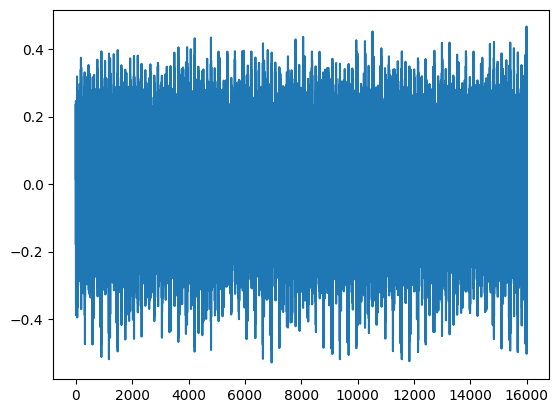

In [10]:
sns.lineplot(audio[5 * 16000: 6 * 16000])

In [11]:
def usable_data(fn):
    audio, sr = librosa.load(os.path.join('horns', fn), sr=16000, mono=True)
    return audio[5 * sr : 6 * sr]

anchoring_data['audio'] = anchoring_data['file_name'].apply(usable_data)

In [12]:
anchoring_data

,file_name,labels,audio
0,12-VIBROMAX-VX-PAIR.mp3,CAR/TRUCK,"[0.27441505, -0.21807452, -0.21259846, 0.11278..."
1,5-MEGASONIC-MS-PAIR.mp3,CAR/TRUCK/BUS,"[0.27104467, -0.0011240095, -0.45411745, -0.37..."
2,19-Supersonic-SS-PAIR.mp3,CAR/TRUCK/JEEP,"[-0.43138474, -0.41799343, 0.20755395, 0.54530..."
3,RSA2-Pair.mp3,CAR/TRUCK,"[-0.082663134, -0.20827158, -0.109646335, 0.02..."
4,14-VIBROSONIC-VS-PAIR.mp3,CAR/TRUCK/JEEP/TRACTOR,"[-0.24529836, 0.29467046, 0.35949934, -0.13011..."
5,20-R125-R125-PAIR.mp3,CAR/TRUCK/JEEP/TRACTOR,"[0.366105, 0.5941705, 0.0014196038, -0.5461574..."
6,Supertone-Pair.mp3,CAR/TWO WHEELER,"[-0.10557088, 0.23596989, 0.40089506, 0.228630..."
7,13-VIBROMINI-VM-PAIR.mp3,CAR/TRACTOR/TWO WHEELER,"[-0.00027319358, -0.00021853978, -0.0001354827..."
8,11-SPIDER-ECO-BLACK-SE-PAIR.mp3,TWO WHEELER/CAR/JEEP,"[-0.19487502, 0.0147623755, 0.21202356, 0.0716..."
9,1-CLEARTONE-BLACK-CB-PAIR.mp3,TWO WHEELER/CAR/JEEP,"[0.14891195, -0.12898393, -0.16490954, 0.07717..."


## Load YAMNet and encodings

In [13]:
yamnet_model_download = kagglehub.model_download('google/yamnet/tensorFlow2/yamnet')
yamnet = tf.saved_model.load(yamnet_model_download)

classes_path = os.path.join(yamnet_model_download, 'assets/yamnet_class_map.csv')
classes = pd.read_csv(classes_path)

E0000 00:00:1779652332.088736   33819 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [14]:
_, embed, _ = yamnet(audio[5 * 16000 : 6 * 16000])
embed.numpy().mean(axis=0)

array([0.        , 0.        , 0.14916019, ..., 0.721987  , 0.        ,
       0.        ], dtype=float32)

In [15]:
def gen_anchors(ad):
    _, embeddings, _ = yamnet(ad)
    return embeddings.numpy()[0]
anchoring_data['embedding'] = anchoring_data['audio'].apply(gen_anchors)

In [16]:
anchoring_data

,file_name,labels,audio,embedding
0,12-VIBROMAX-VX-PAIR.mp3,CAR/TRUCK,"[0.27441505, -0.21807452, -0.21259846, 0.11278...","[0.0, 0.0, 0.08300633, 2.9436324, 0.0, 0.0, 0...."
1,5-MEGASONIC-MS-PAIR.mp3,CAR/TRUCK/BUS,"[0.27104467, -0.0011240095, -0.45411745, -0.37...","[0.0, 0.0, 0.0, 2.9426756, 0.0, 0.0, 0.0, 3.91..."
2,19-Supersonic-SS-PAIR.mp3,CAR/TRUCK/JEEP,"[-0.43138474, -0.41799343, 0.20755395, 0.54530...","[0.0, 0.0, 0.0, 1.9778099, 0.0, 0.0, 0.0, 3.66..."
3,RSA2-Pair.mp3,CAR/TRUCK,"[-0.082663134, -0.20827158, -0.109646335, 0.02...","[0.0, 0.0, 0.007266792, 1.892058, 0.0, 0.0, 0...."
4,14-VIBROSONIC-VS-PAIR.mp3,CAR/TRUCK/JEEP/TRACTOR,"[-0.24529836, 0.29467046, 0.35949934, -0.13011...","[0.0, 0.0, 0.0, 1.5934153, 0.0, 0.0, 0.0, 2.29..."
5,20-R125-R125-PAIR.mp3,CAR/TRUCK/JEEP/TRACTOR,"[0.366105, 0.5941705, 0.0014196038, -0.5461574...","[0.0, 0.0, 0.19576246, 1.3435559, 0.0, 0.0, 0...."
6,Supertone-Pair.mp3,CAR/TWO WHEELER,"[-0.10557088, 0.23596989, 0.40089506, 0.228630...","[0.0, 0.0, 0.14112741, 0.047581673, 0.0, 0.0, ..."
7,13-VIBROMINI-VM-PAIR.mp3,CAR/TRACTOR/TWO WHEELER,"[-0.00027319358, -0.00021853978, -0.0001354827...","[0.0, 0.0, 0.0, 1.6880398, 0.0, 0.0, 0.0, 1.92..."
8,11-SPIDER-ECO-BLACK-SE-PAIR.mp3,TWO WHEELER/CAR/JEEP,"[-0.19487502, 0.0147623755, 0.21202356, 0.0716...","[0.0, 0.0, 0.0, 0.91740847, 0.0, 0.0, 0.0, 0.0..."
9,1-CLEARTONE-BLACK-CB-PAIR.mp3,TWO WHEELER/CAR/JEEP,"[0.14891195, -0.12898393, -0.16490954, 0.07717...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5182071,..."


In [17]:
def get_top_percentile(scores, p = 0.95):
    select_best = np.argsort(scores)[::-1]
    
    total = np.sum(scores)
    indx = np.argmax(np.cumsum(scores.numpy()[select_best] / total) >= p) + 1
    
    return ' | '.join(classes['display_name'][select_best][:indx]), np.sum(scores.numpy()[select_best[:5]]) / total

In [18]:
def get_horn_distances(embed):
    T = 2.5
    distances = anchoring_data['embedding'].apply(lambda a: -scipy.spatial.distance.euclidean(a, embed))
    probs = scipy.special.softmax(distances)
    return probs

In [19]:
adev = pyaudio.PyAudio()
stream = adev.open(rate=16000, channels=1, format=pyaudio.paFloat32, input=True, frames_per_buffer=16000)
rec = stream.read(num_frames=16000 * 10, exception_on_overflow=False)
stream.close()
audio = np.frombuffer(rec, dtype=np.float32)
Audio(audio, rate=16000)

ALSA lib pcm_dmix.c:1000:(snd_pcm_dmix_open) unable to open slave
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.rear
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.center_lfe
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.side
ALSA lib pcm_route.c:878:(find_matching_chmap) Found no matching channel map
ALSA lib pcm_dmix.c:1000:(snd_pcm_dmix_open) unable to open slave
Cannot connect to server socket err = No such file or directory
Cannot connect to server request channel
jack server is not running or cannot be started
JackShmReadWritePtr::~JackShmReadWritePtr - Init not done for -1, skipping unlock
JackShmReadWritePtr::~JackShmReadWritePtr - Init not done for -1, skipping unlock


In [20]:
scores, embeddings, _ = yamnet(audio)

In [21]:
get_top_percentile(scores[11], 0.9)

('Silence | Vehicle | Inside, small room | White noise | Motor vehicle (road) | Car | Animal | Bus | Outside, urban or manmade | Rustle | Tick | Domestic animals, pets | Noise | Mechanisms | Cat | Wild animals | Outside, rural or natural | Rodents, rats, mice | Mechanical fan | Bird | Wind | Engine | Boat, Water vehicle | Clock | Truck | Rustling leaves | Microwave oven | Tick-tock | Sound effect | Inside, large room or hall | Medium engine (mid frequency) | Television | Rail transport | Car passing by | Door | Liquid | Train | Motorboat, speedboat | Snake | Spray | Mouse | Printer | Dog | Beep, bleep | Idling | Pigeon, dove | Heavy engine (low frequency) | Water | Meow | Accelerating, revving, vroom | Gurgling | Bird vocalization, bird call, bird song | Livestock, farm animals, working animals | Tap | Vehicle horn, car horn, honking | Clatter | Vibration | Breathing | Speech | Coo | Fowl | Railroad car, train wagon',
 0.39030853)

In [22]:
results = pd.DataFrame(range(0, len(scores), 1), columns=['time'])
extra = pd.DataFrame(list(map(lambda indx: get_top_percentile(scores[indx], 0.9), results['time'])), columns=['classes', 'confidence'])
results = results.join(extra)
results['time'] = results['time'].apply(lambda a: a / 2)
results

,time,classes,confidence
0,0.0,"Vehicle | Wind | Outside, urban or manmade | R...",0.347880
1,0.5,Wind | Vehicle | Rustling leaves | Wind noise ...,0.449724
2,1.0,Vehicle | Silence | White noise | Motor vehicl...,0.277035
3,1.5,Vehicle | Silence | Motor vehicle (road) | Ins...,0.322172
4,2.0,Silence | White noise | Vehicle | Rustle | Mot...,0.406296
5,2.5,White noise | Vehicle | Rustle | Silence | Win...,0.267144
6,3.0,Vehicle | Silence | White noise | Car | Motor ...,0.326044
7,3.5,"Inside, small room | Animal | Cat | Vehicle | ...",0.248544
8,4.0,"Inside, small room | Silence | Rodents, rats, ...",0.267761
9,4.5,"Silence | Inside, small room | Rustle | Tick |...",0.468849


In [23]:
results.loc[5]

time                                                        2.5
classes       White noise | Vehicle | Rustle | Silence | Win...
confidence                                             0.267144
Name: 5, dtype: object

In [24]:
foo_labels = [ f'{a};{b.split('.')[0]}' for a, b in enumerate(anchoring_data['file_name'], start=1)]

In [25]:
alabs = pd.DataFrame(np.array(list(map(get_horn_distances, embeddings))), columns=foo_labels)
alabs

,1;12-VIBROMAX-VX-PAIR,2;5-MEGASONIC-MS-PAIR,3;19-Supersonic-SS-PAIR,4;RSA2-Pair,5;14-VIBROSONIC-VS-PAIR,6;20-R125-R125-PAIR,7;Supertone-Pair,8;13-VIBROMINI-VM-PAIR,9;11-SPIDER-ECO-BLACK-SE-PAIR,10;1-CLEARTONE-BLACK-CB-PAIR,...,20;18-WINDTONE-90-W90-PAIR,21;17-WINDTONE-75-VERTICAL-W75V-PAIR,22;W70-Pair,23;16-WINDTONE-75-W75-PAIR,24;Electronic-Horn,25;17-WINDTONE-75-ElectronicMulti-function-horn,26;Electromini,27;2-BACKUP-ALARM-TYPE-C,28;Backup-alarm-TYPE-BF,29;3-BACKUP-ALARM-TYPE-B
0,0.087184,0.000010,0.000180,0.078929,0.014268,0.000104,0.000611,0.000260,0.020604,0.004557,...,0.000051,0.000045,0.001605,0.000012,0.000012,0.088187,0.000796,0.044777,0.569682,0.070510
1,0.062286,0.000012,0.000190,0.047243,0.013264,0.000093,0.000659,0.000222,0.018509,0.004555,...,0.000047,0.000048,0.001643,0.000012,0.000012,0.062436,0.000719,0.055608,0.640277,0.075208
2,0.085399,0.000009,0.000159,0.076602,0.011818,0.000086,0.000669,0.000211,0.023175,0.004000,...,0.000046,0.000041,0.001511,0.000011,0.000011,0.078666,0.000777,0.050874,0.552849,0.096859
3,0.096191,0.000009,0.000147,0.084351,0.011397,0.000089,0.000649,0.000222,0.026150,0.003760,...,0.000053,0.000046,0.001499,0.000011,0.000011,0.099647,0.000734,0.046810,0.517462,0.094803
4,0.081944,0.000008,0.000136,0.079055,0.009778,0.000086,0.000755,0.000220,0.026114,0.004236,...,0.000047,0.000040,0.001333,0.000010,0.000010,0.081754,0.000701,0.054929,0.557932,0.085669
5,0.084588,0.000008,0.000148,0.069501,0.010463,0.000081,0.000747,0.000197,0.025121,0.003908,...,0.000047,0.000044,0.001582,0.000011,0.000011,0.080583,0.000750,0.054918,0.544748,0.106545
6,0.101631,0.000010,0.000177,0.111136,0.012390,0.000104,0.000774,0.000283,0.025928,0.004529,...,0.000058,0.000051,0.001756,0.000013,0.000013,0.096648,0.000842,0.053728,0.450384,0.120617
7,0.110799,0.000007,0.000107,0.058740,0.007775,0.000059,0.000810,0.000137,0.028779,0.002983,...,0.000037,0.000035,0.001153,0.000008,0.000008,0.084433,0.000743,0.061971,0.546405,0.083310
8,0.041045,0.000007,0.000116,0.025614,0.007970,0.000060,0.000641,0.000139,0.014373,0.003508,...,0.000027,0.000028,0.001061,0.000009,0.000009,0.038027,0.000732,0.062607,0.701804,0.089785
9,0.045590,0.000005,0.000083,0.036290,0.005898,0.000053,0.000683,0.000116,0.017166,0.003295,...,0.000025,0.000022,0.000781,0.000005,0.000005,0.044976,0.000528,0.067821,0.717463,0.050137


In [26]:
results['anchor_horn'] = (alabs > 0.3).sum(axis=1)
results

,time,classes,confidence,anchor_horn
0,0.0,"Vehicle | Wind | Outside, urban or manmade | R...",0.347880,1
1,0.5,Wind | Vehicle | Rustling leaves | Wind noise ...,0.449724,1
2,1.0,Vehicle | Silence | White noise | Motor vehicl...,0.277035,1
3,1.5,Vehicle | Silence | Motor vehicle (road) | Ins...,0.322172,1
4,2.0,Silence | White noise | Vehicle | Rustle | Mot...,0.406296,1
5,2.5,White noise | Vehicle | Rustle | Silence | Win...,0.267144,1
6,3.0,Vehicle | Silence | White noise | Car | Motor ...,0.326044,1
7,3.5,"Inside, small room | Animal | Cat | Vehicle | ...",0.248544,1
8,4.0,"Inside, small room | Silence | Rodents, rats, ...",0.267761,1
9,4.5,"Silence | Inside, small room | Rustle | Tick |...",0.468849,1


In [27]:
(alabs > 0.12).sum()

1;12-VIBROMAX-VX-PAIR                               0
2;5-MEGASONIC-MS-PAIR                               0
3;19-Supersonic-SS-PAIR                             0
4;RSA2-Pair                                         0
5;14-VIBROSONIC-VS-PAIR                             0
6;20-R125-R125-PAIR                                 0
7;Supertone-Pair                                    0
8;13-VIBROMINI-VM-PAIR                              0
9;11-SPIDER-ECO-BLACK-SE-PAIR                       0
10;1-CLEARTONE-BLACK-CB-PAIR                        0
11;21-R100-R100-PAIR                                0
12;6-R-95-R95-PAIR                                  0
13;CLEARTONE-MINI                                   0
14;8-ROOTS-90-R90-PAIR                              0
15;10-SMARTONE-SM70-PAIR                            0
16;R82-Pair                                         0
17;7-ROOTS-75-R75-PAIR                              0
18;22-R70-NEW-R70-NEW-PAIR                          0
19;9-S70-S70-PAIR           

## Setting up a server using fastapi

In [28]:
app = FastAPI()
origins = ['*']
app.add_middleware(
    CORSMiddleware,
    allow_origins=origins,
    allow_credentials=True,
    allow_methods=['*'],
    allow_headers=['*']
)

In [29]:
app.mount("/static", StaticFiles(directory="static"), name="static")

In [30]:
@app.get("/")
async def redirect_typer():
    return RedirectResponse("/static/index.html")

In [31]:
@app.post('/recognize')
async def get_predictions(file : UploadFile = File()):
    with tempfile.NamedTemporaryFile(suffix='.webm') as foo:
        foo.write(file.file.read())
        foo.flush()

        audio_data, _ = librosa.load(foo.name, src=16000, mono=True)
        scores, embeddings, spectogram = yamnet(audio_data)

        results = pd.DataFrame(range(0, len(scores), 1), columns=['time'])
        extra = pd.DataFrame(list(map(lambda indx: get_top_percentile(scores[indx], 0.9), results['time'])), columns=['classes', 'confidence'])
        results = results.join(extra)
        results['time'] = results['time'].apply(lambda a: a / 2)

        foo_labels = [ f'{a};{b}' for a, b in enumerate(anchoring_data['labels'], start=1)]
        alabs = pd.DataFrame(np.array(list(map(get_horn_distances, embeddings))), columns=foo_labels)

        results['anchor_horn'] = (alabs > 0.4).sum(axis=1)

        summary = (alabs > 0.4).sum()

        return {'result': results.to_dict(), 'summary': summary.to_dict()}

In [32]:
serv_config = uvicorn.Config(app, host="0.0.0.0", port=8080)
server = uvicorn.Server(serv_config)

In [33]:
nest_asyncio.apply()

In [34]:
def launch_server():
    if server.started:
        print('Already Started')
        return
    loop = asyncio.get_event_loop()
    loop.create_task(server.serve())

In [35]:
def drop_server():
    asyncio.create_task(server.shutdown())

In [40]:
#launch_server()

In [41]:
#drop_server()